<a href="https://colab.research.google.com/github/YaKhom/Titanic_Dataset-EDA-/blob/main/Pipeline_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Знакомство с машинным обучением

## Описание задачи и загрузка данных

В этом задании вам нужно обучить линейную регрессию для предсказания стоимости домов в Калифорнии.

Загружаем необходимые библиотеки.

In [1]:
import pandas as pd
import seaborn as sb
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_california_housing

Фиксируем `random_state` для воспроизводимости случайных значений.

In [2]:
RANDOM_STATE = 42

Загрузим данные и сформируем из них матрицу объект-признак `X` и вектор `y`, содержащий целевую переменную.

In [3]:
Data = fetch_california_housing(as_frame=True)

X = Data['data']
y = Data['target']

Посмотрим первые пять записей набора данных.

In [4]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## Задание 1

 Сколько строк и столбцов в матрице `X`?

In [11]:
# ваш код здесь
X.shape
#X.info()

(20640, 8)

Посмотрим на зависимость стоимости домов (целевой переменной `y`) от признака `MedInc` (`Median Income`).
Для этого можно нарисовать диаграмму рассеяния.

Text(0, 0.5, 'House Price')

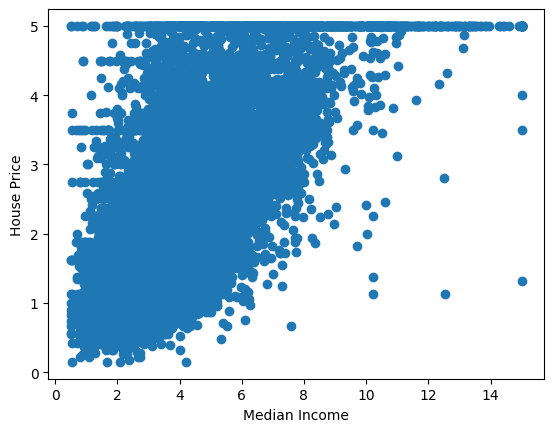

In [12]:
plt.scatter(X['MedInc'], y)
plt.xlabel('Median Income')
plt.ylabel('House Price')

По диаграмме видно, что чем больше `Median Income`, тем больше `House Price`, то есть видна прямая зависимость целевой переменной от признака `MedInc`.

## Задание 2

Постройте диаграмму рассеяния, отображающую зависимость целевой переменной от признака `Latitude`.
Какая это зависимость?

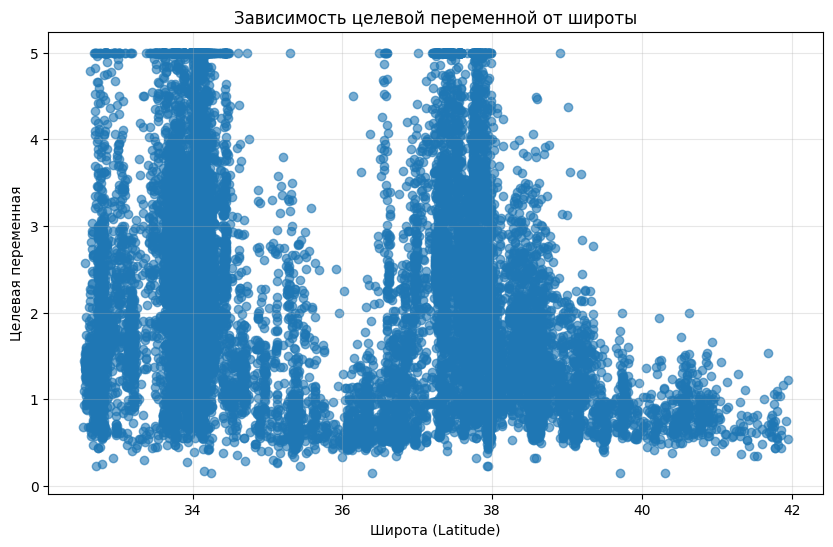

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X['Latitude'], y, alpha=0.6)
plt.xlabel('Широта (Latitude)')
plt.ylabel('Целевая переменная')
plt.title('Зависимость целевой переменной от широты')
plt.grid(True, alpha=0.3)
plt.show()



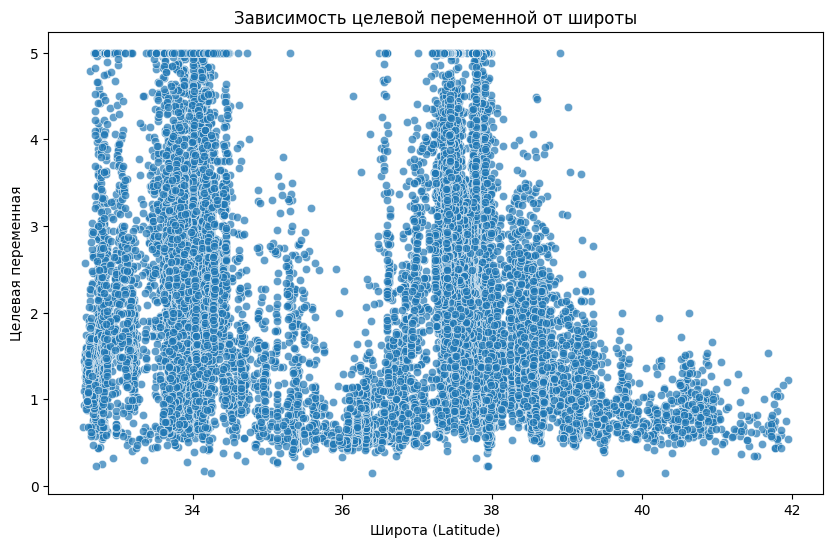

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X['Latitude'], y=y, alpha=0.7)
plt.title('Зависимость целевой переменной от широты')
plt.xlabel('Широта (Latitude)')
plt.ylabel('Целевая переменная')
plt.show()


Ещё немного поисследуем данные. Полноценный разведочный анализ в рамках этого задания, конечно, не провести, но какие-то инструменты мы потрогаем.

Давайте построим тепловую карту корреляций.

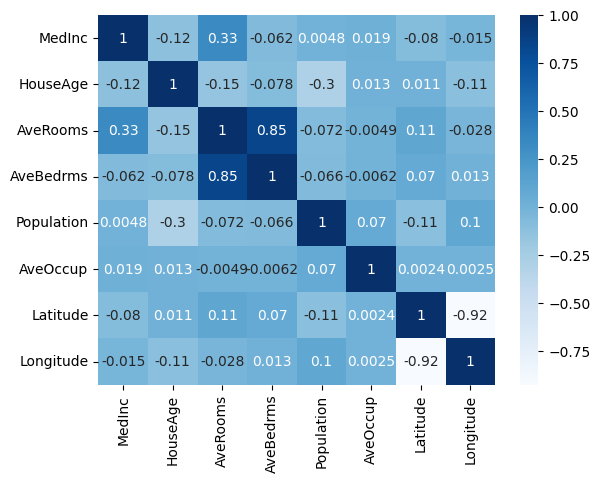

In [17]:
corr = X.corr()
sb.heatmap(corr, cmap="Blues", annot=True);

По этой матрице корреляций видно, что два наиболее зависимых признака - это `AveRooms` и `AveBedrms`.

Но интереснее посмотреть, какой признак имеет наибольшую корреляцию с целевой переменной!

## Задание 3

Добавьте к матрице `X` столбец `y` и постройте матрицу корреляций.
Какой признак имеет наибольшую по модулю корреляцию с таргетом?
После выполнения задания удалите добавленный столбец `y` из матрицы `X`.

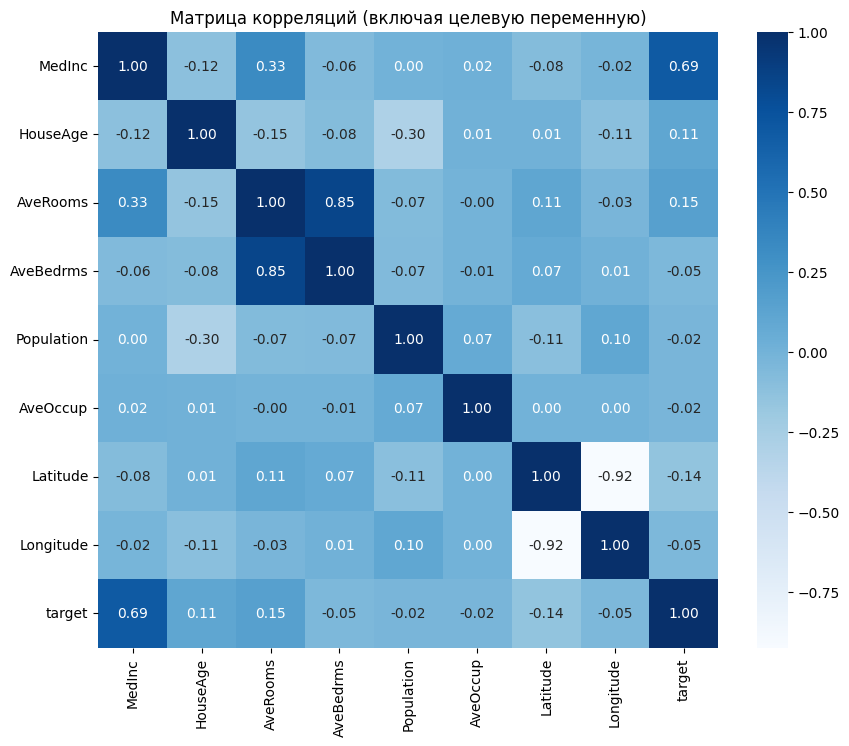

Признак с наибольшей по модулю корреляцией: MedInc
Значение корреляции: 0.688


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Добавляем столбец y к матрице X с временным именем 'target'
X_with_target = X.copy()  # создаём копию, чтобы не менять оригинальный X
X_with_target['target'] = y

# Строим матрицу корреляций
corr = X_with_target.corr()

# Визуализируем матрицу корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="Blues", annot=True, fmt=".2f")
plt.title("Матрица корреляций (включая целевую переменную)")
plt.show()

# Находим признак с наибольшей по модулю корреляцией с target
target_correlations = corr['target'].drop('target')  # исключаем самокорреляцию target с собой
max_corr_feature = target_correlations.abs().idxmax()
max_correlation = target_correlations[max_corr_feature]

print(f"Признак с наибольшей по модулю корреляцией: {max_corr_feature}")
print(f"Значение корреляции: {max_correlation:.3f}")

# Удаляем добавленный столбец из копии (оригинальный X не изменён)
# Поскольку мы работали с копией, оригинальный X остаётся без изменений


Разбейте данные на тренировочную и тестовую часть (в тест отправьте 25% данных).

In [19]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state= 42, shuffle=True)

##Задание 4

Сколько объектов попали в тест?

Обучите линейную регрессию с параметрами по умолчанию на тренировочных данных и сделайте предсказание на тестовых данных.

In [20]:
print(f"Количество объектов в тестовой выборке: {len(Xtest)}")

Количество объектов в тестовой выборке: 5160


In [21]:
from sklearn.linear_model import LinearRegression

# Создаём экземпляр модели с параметрами по умолчанию
model = LinearRegression()


# Обучаем модель на тренировочных данных
model.fit(Xtrain, ytrain)

# Делаем предсказания на тестовых данных
y_pred = model.predict(Xtest)

print(f"Предсказания на тестовой выборке (первые 10 значений): {y_pred[:10]}")

Предсказания на тестовой выборке (первые 10 значений): [0.72412832 1.76677807 2.71151581 2.83601179 2.603755   2.01196798
 2.64015877 2.16615338 2.74656582 3.90415813]


## Задание 5

Вычислите значение метрики *MSE* на тестовых данных.
Ответ округлите до десятых.

In [22]:
from sklearn.metrics import mean_squared_error

# Вычисляем MSE на тестовых данных
mse = mean_squared_error(ytest, y_pred)

# Округляем до десятых
mse_rounded = round(mse, 1)

print(f"MSE на тестовых данных (округлённый до десятых): {mse_rounded}")

MSE на тестовых данных (округлённый до десятых): 0.5
